In [2]:
import pandas

data = pandas.read_csv("datasets/supermarket_data.csv")
data

,Invoice ID,city,customertype,gender,product,itemprice,quantity,total,date,time,payment,customersalary,rating
0,750-67-8428,Nairobi,Member,Female,Health and beauty,74.69,7,548.9715,1/5/2019,13:08,MPESA,26.1415,9.1
1,226-31-3081,Nakuru,Normal,Female,Electronic accessories,15.28,5,80.2200,3/8/2019,10:29,Cash,3.8200,9.6
2,631-41-3108,Nairobi,Normal,Female,Home and lifestyle,46.33,7,340.5255,3/3/2019,13:23,Credit card,16.2155,7.4
3,123-19-1176,Nairobi,Member,Female,Health and beauty,58.22,8,489.0480,1/27/2019,20:33,MPESA,23.2880,8.4
4,373-73-7910,Nairobi,Normal,Female,Health and beauty,86.31,7,634.3785,2/8/2019,10:37,MPESA,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,233-67-5758,Nakuru,Normal,Male,Health and beauty,40.35,1,42.3675,1/29/2019,13:46,MPESA,2.0175,6.2
997,303-96-2227,Mombasa,Normal,Female,Home and lifestyle,97.38,10,1022.4900,3/2/2019,17:16,MPESA,48.6900,4.4
998,727-02-1313,Nairobi,Member,Male,Food and beverages,31.84,1,33.4320,2/9/2019,13:22,Cash,1.5920,7.7
999,347-56-2442,Nairobi,Normal,Male,Home and lifestyle,65.82,1,69.1110,2/22/2019,15:33,Cash,3.2910,4.1


In [3]:
# use the describe function
data.describe()

,itemprice,quantity,total,customersalary,rating
count,998.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,55.686523,5.505495,322.739927,15.368568,6.972527
std,26.538665,2.925444,245.867115,11.707958,1.717729
min,10.080000,1.000000,10.678500,0.508500,4.000000
25%,32.825000,3.000000,122.524500,5.834500,5.500000
50%,55.230000,5.000000,253.680000,12.080000,7.000000
75%,78.040000,8.000000,471.030000,22.430000,8.500000
max,99.960000,10.000000,1042.650000,49.650000,10.000000


In [4]:
# we have noticed that the collumn item price column ,contains 3 empty slotes
# we need to fill these empty slots with a value and in this case we shall feel with the ean of the column
data["itemprice"] = data["itemprice"].fillna(55)


# describe the data again
data.describe()

,itemprice,quantity,total,customersalary,rating
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,55.684466,5.505495,322.739927,15.368568,6.972527
std,26.498854,2.925444,245.867115,11.707958,1.717729
min,10.080000,1.000000,10.678500,0.508500,4.000000
25%,32.900000,3.000000,122.524500,5.834500,5.500000
50%,55.040000,5.000000,253.680000,12.080000,7.000000
75%,77.950000,8.000000,471.030000,22.430000,8.500000
max,99.960000,10.000000,1042.650000,49.650000,10.000000


In [5]:
# get the number of entries in a given column
data.groupby("gender").size()

gender
Female    625
Male      376
dtype: int64

In [6]:
data.groupby("customertype").size()

customertype
Member    500
Normal    495
dtype: int64

In [7]:
data.groupby("city").size()


city
Mombasa    300
Nairobi    395
Nakuru     306
dtype: int64

In [8]:
data.groupby("payment").size()

payment
Cash           275
Credit card    255
MPESA          471
dtype: int64

In [9]:
# combining multiple columns
data.groupby(["city","payment"]).size()

city     payment    
Mombasa  Cash            73
         Credit card     83
         MPESA          144
Nairobi  Cash           118
         Credit card     98
         MPESA          179
Nakuru   Cash            84
         Credit card     74
         MPESA          148
dtype: int64

In [10]:
# import the modules
import seaborn as sns
import matplotlib.pyplot as plt


C:\Users\Sylvia\AppData\Local\Temp\ipykernel_15748\1602506972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender",data=data, palette="dark")


Text(0, 0.5, 'Total count of individuals')

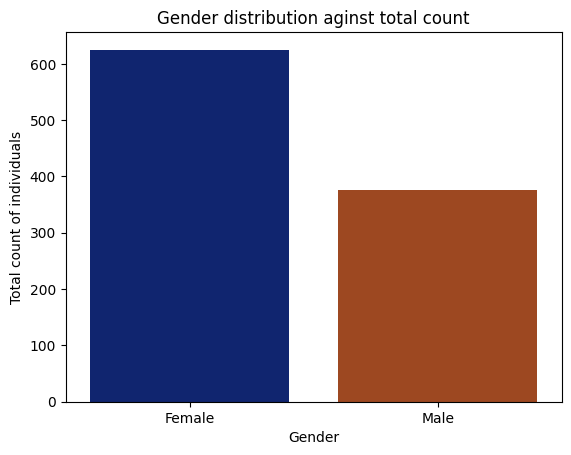

In [11]:
# below is a count plot showing destribution of males to female
sns.countplot(x="gender",data=data, palette="dark")
plt.title("Gender distribution aginst total count")
plt.xlabel("Gender")
plt.ylabel("Total count of individuals")   


C:\Users\Sylvia\AppData\Local\Temp\ipykernel_15748\1289383690.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="product",data=data, palette="dark")


Text(0, 0.5, 'Total count of individuals')

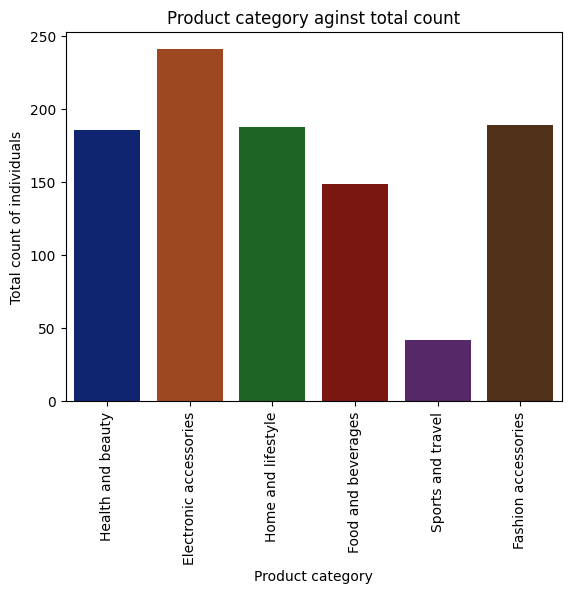

In [12]:
sns.countplot(x="product",data=data, palette="dark")
plt.title("Product category aginst total count")
plt.xticks(rotation=90)
plt.xlabel("Product category")
plt.ylabel("Total count of individuals")


<Axes: xlabel='gender', ylabel='count'>

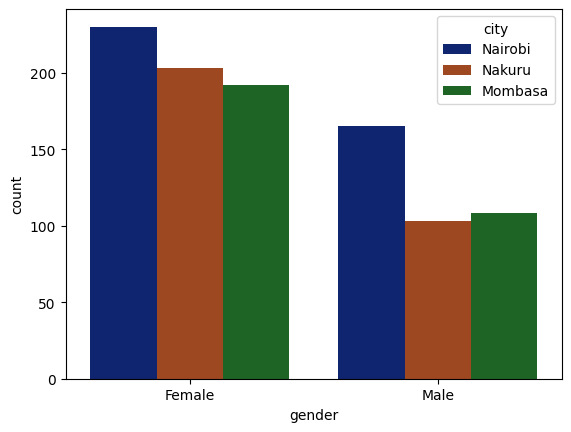

In [13]:
# below is a count plot that has two columns
sns.countplot(x="gender",hue="city",data=data, palette="dark")


<Axes: >

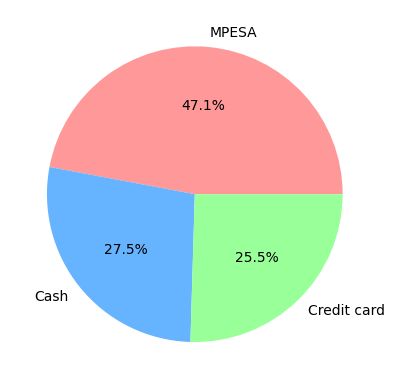

In [14]:
# below is a pie plot
data["payment"].value_counts().plot.pie(autopct="%1.1f%%", colors=["#ff9999","#66b3ff","#99ff99","#ffcc99"])

C:\Users\Sylvia\AppData\Local\Temp\ipykernel_15748\1573954893.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="gender", data=data, palette="dark")


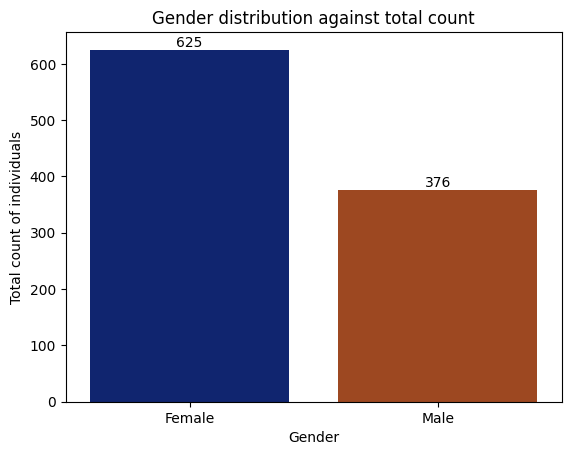

In [15]:
# 1. Assign the plot to a variable named 'ax'
ax = sns.countplot(x="gender", data=data, palette="dark")

# 2. Add the labels using the container from the plot
# Loop through all containers to label every bar automatically
for container in ax.containers:
    ax.bar_label(container)
     #ax = sns.countplot(...): This creates the plot and stores the Axes object in ax
# ax.containers[0]: Seaborn creates a "container" for the bars it draws
# containers[0] specifically references the group of bars in your chart
# ax.bar_label(...): This automatically extracts the heights of the bars and places them as text labels above the bars.

# Rest of your formatting
plt.title("Gender distribution against total count")
plt.xlabel("Gender")
plt.ylabel("Total count of individuals")

plt.show()

C:\Users\Sylvia\AppData\Local\Temp\ipykernel_15748\1779012897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="gender", data=data, palette="spring")


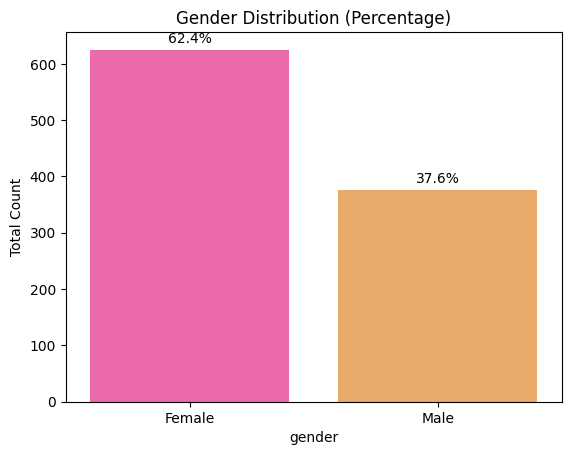

In [17]:

# 1. Get the total count of the data
total = len(data['gender'])
# 2. Create the plot
ax = sns.countplot(x="gender", data=data, palette="spring")
# 3. Calculate percentages and add them as labels
for container in ax.containers:
    # Create labels: (bar height / total) * 100
    labels = [f'{(v/total)*100:0.1f}%'
               for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)
plt.title("Gender Distribution (Percentage)")
plt.ylabel("Total Count")
plt.show()

<Axes: xlabel='quantity', ylabel='itemprice'>

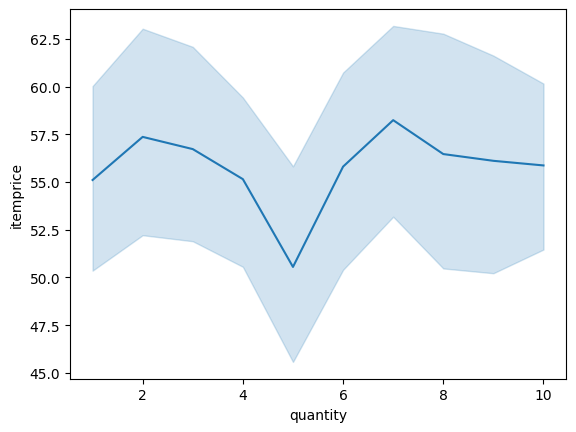

In [18]:
sns.lineplot(x="quantity",y="itemprice",data=data)

In [ ]:
# To accurately count the blanks
# print(data["customertype"].isnull().sum())
# View the specific problematic rows
# data[data["customertype"].isnull()]
# To include the blanks, the (Get the number of entries in  given column) function
# data.groupby("customertype").size()
# Is overwritten by:
data.groupby("customertype", dropna=False).size()